# Anomaly Detection


In [1]:
from collections import namedtuple
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import pandas as pd
from anomaly import (
    apply_mean_threshold,
    apply_rolling_std_threshold,
    apply_zscore_threshold,
    plot_anomalies,
    plot_anomalous_windows,
)
from util import (
    load_building_df,
    plot_dataframe,
    show_overview_for_value,
)

%reload_ext autoreload
%autoreload 2

## Pipeline

Passi:

1. Caricamento e pulizia del dataset
2. Feature engineering: aggiunta di features aventi l'obiettivo di effettuare l'anomaly detection (esempio: Z-Score per TotW)
3. Anomaly detection: usando le feature appena individuate, effettua l'anomaly detection scegliendo tra varie strategie
4. Raccolta e visualizzazione dei risultati


## DataFrame Setup


(0.0, 23.268)

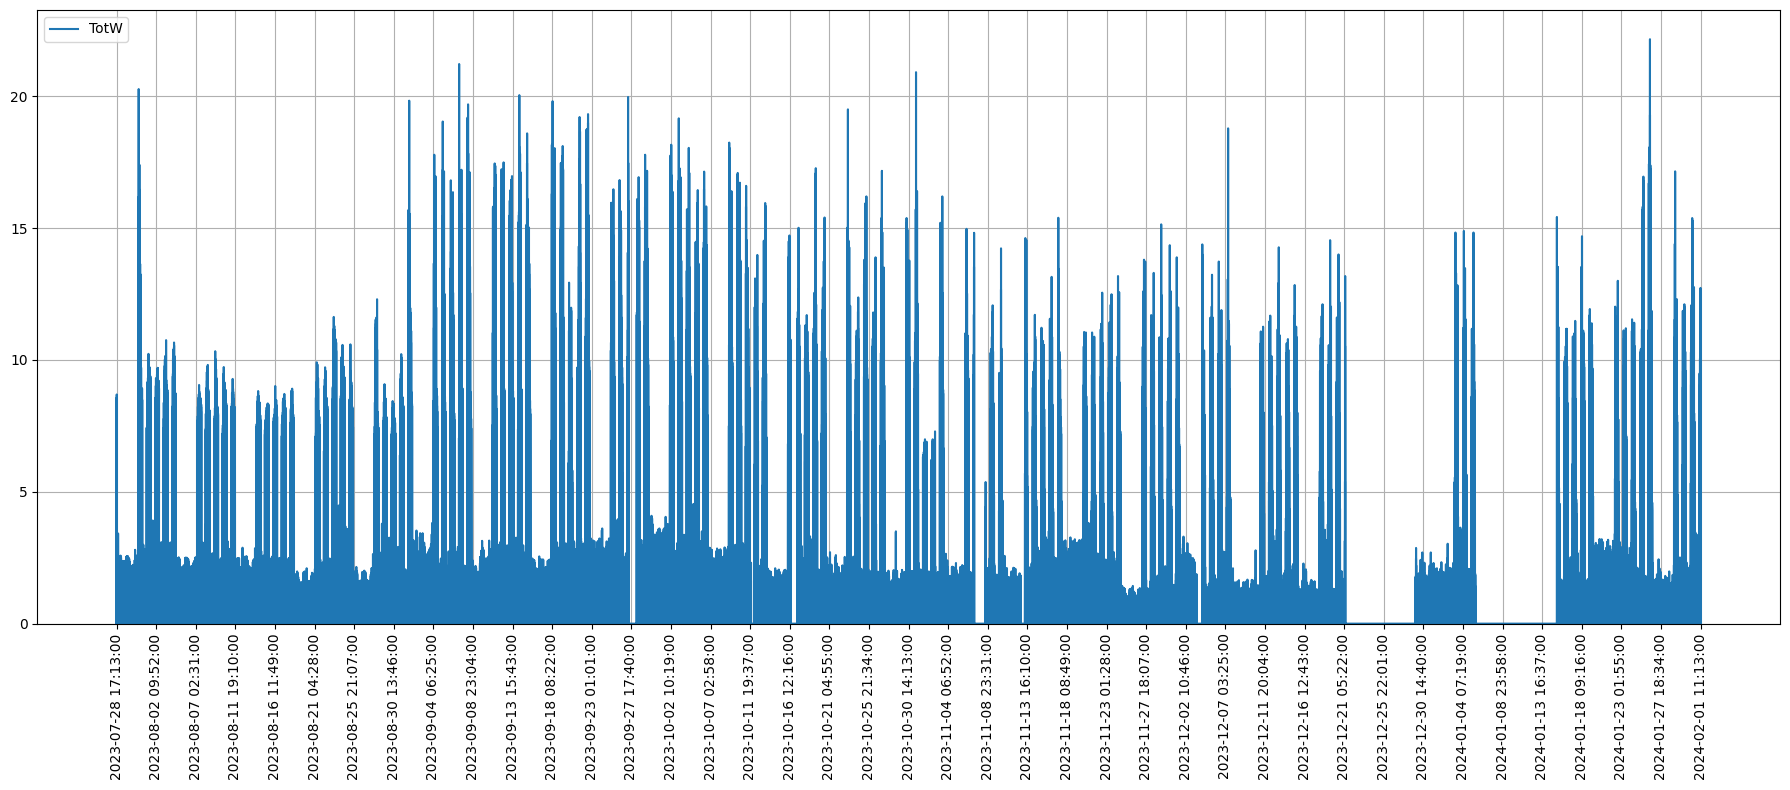

In [2]:
# df = load_building_df(
#     "TotW",
#     "ED14_20240301.csv",
#     "PM5320",
#     "ARCH_FM",
#     resample="min",
# )

# df = load_building_df(
#     "TotW",
#     "ED18_20240301.csv",
#     "GAVAZZI_WM30",
#     "ED18_FM",
#     resample="min",
# )

df = load_building_df(
    "TotW",
    "ASILO_20240301.csv",
    "PM5320",
    "ASILO.GEN",
    resample="min",
)

plot_dataframe(df, ["TotW"])
plt.ylim(0)

In [3]:
df.index = df.index.strftime("%Y-%m-%d %H:%M:%S")  # type: ignore

df_agg = df.groupby("dayofweek").agg({"TotW": ["min", "max", "mean", "std"]})
df_agg.style.background_gradient()

## Anomaly detection tramite Z-Score


### Giorni lavorativi


In [4]:
df_working = df[df["dayofweek"].isin(range(5))]
show_overview_for_value(df_working, "TotW")

In [5]:
df_working.loc[:, "TotW_zscore"] = (
    df_working["TotW"] - df_working["TotW"].mean()
) / df_working["TotW"].std(ddof=0)

show_overview_for_value(df_working, "TotW_zscore")

/tmp/ipykernel_29404/330554193.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_working.loc[:, "TotW_zscore"] = (


In [26]:
# decide among different thresholding strategies
apply_zscore_threshold(df_working, 6)
# apply_mean_threshold(df_working, "TotW")
# apply_rolling_std_threshold(df_working, "TotW", window=10, multiplier=1.3)

In [27]:
start = "2024-01-01"
end = "2024-02-01"

df_working = df_working[start:]

# set default value to initialize column
df_working.loc[:, "anomalous"] = False

# handle anomalies here
# mark data points whose zscore exceeds the threshold
df_working.loc[:, "high_flag"] = df_working.apply(
    lambda x: True if x["TotW_zscore"] >= x["Threshold"] else False,
    axis=1,
)


# todo: mark data points as anomalous if zscore is lower than baseline
# (this is a placeholder)
df_working.loc[:, "low_flag"] = df_working.apply(
    lambda x: True if x["TotW_zscore"] < 0 else False,
    axis=1,
)

# todo: in the future, set this to 1 if any anomaly flag is turned on
df_working.loc[:, "anomalous"] = df_working.apply(
    lambda x: True if x["high_flag"] else False,
    axis=1,
)


df_working

,TotW,hour,dayofweek,week,TotW_zscore,Threshold,anomalous,high_flag,low_flag
datetime,,,,,,,,,
2024-01-01 00:00:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:01:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:02:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:03:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:04:00,1.17,0,0,0,0.178601,6.0,False,False,False
...,...,...,...,...,...,...,...,...,...
2024-02-01 11:43:00,0.00,11,3,4,-0.341425,6.0,False,False,True
2024-02-01 11:44:00,0.00,11,3,4,-0.341425,6.0,False,False,True
2024-02-01 11:45:00,0.00,11,3,4,-0.341425,6.0,False,False,True


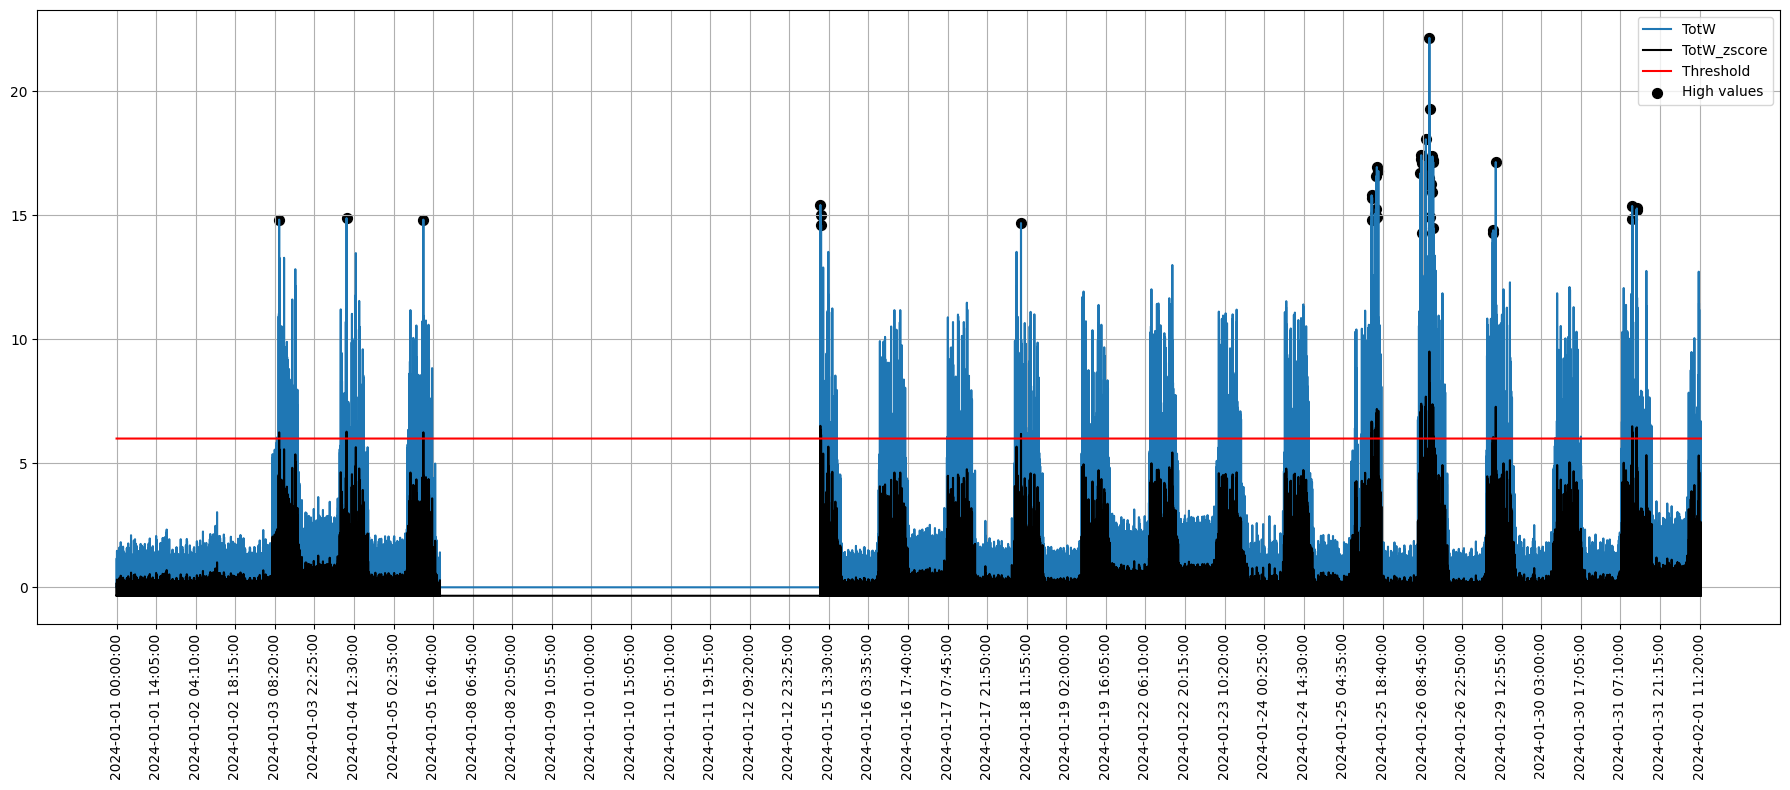

In [28]:
plot_dataframe(
    df_working,
    ["TotW", "TotW_zscore", "Threshold"],
    {"TotW": "#1F77B4", "TotW_zscore": "#000000", "Threshold": "red"},
)

plot_anomalies(df_working)

### Giorni non-lavorativi


In [29]:
df_nonworking = df[(df["dayofweek"].isin([5, 6]))]
df_nonworking

,TotW,hour,dayofweek,week
datetime,,,,
2023-07-29 00:00:00,0.00,0,5,30
2023-07-29 00:01:00,0.00,0,5,30
2023-07-29 00:02:00,0.00,0,5,30
2023-07-29 00:03:00,2.14,0,5,30
2023-07-29 00:04:00,0.00,0,5,30
...,...,...,...,...
2024-01-28 23:55:00,0.00,23,6,4
2024-01-28 23:56:00,0.00,23,6,4
2024-01-28 23:57:00,0.00,23,6,4


In [30]:
show_overview_for_value(df_nonworking, "TotW")

In [31]:
df_nonworking.loc[:, "TotW_zscore"] = (
    df_nonworking["TotW"] - df_nonworking["TotW"].mean()
) / df_nonworking["TotW"].std(ddof=0)

show_overview_for_value(df_nonworking, "TotW_zscore")

/tmp/ipykernel_29404/3756807541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonworking.loc[:, "TotW_zscore"] = (


In [32]:
# "static" approach: if mean is surpassed by n stds, data point is anomalous
df_nonworking.loc[:, "Threshold"] = 6

# mean version (doesn't work - threshold is too low)
# df_nonworking.loc[:, "Threshold"] = df_nonworking["TotW"].mean()

# std version (detects sudden spikes)
# df_nonworking.loc[:, "Threshold"] = df_nonworking["TotW"].rolling(window=10).std() * 1.2

/tmp/ipykernel_29404/1455008095.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonworking.loc[:, "Threshold"] = 6


/tmp/ipykernel_29404/2652397304.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonworking.loc[:, "anomalous"] = "no"


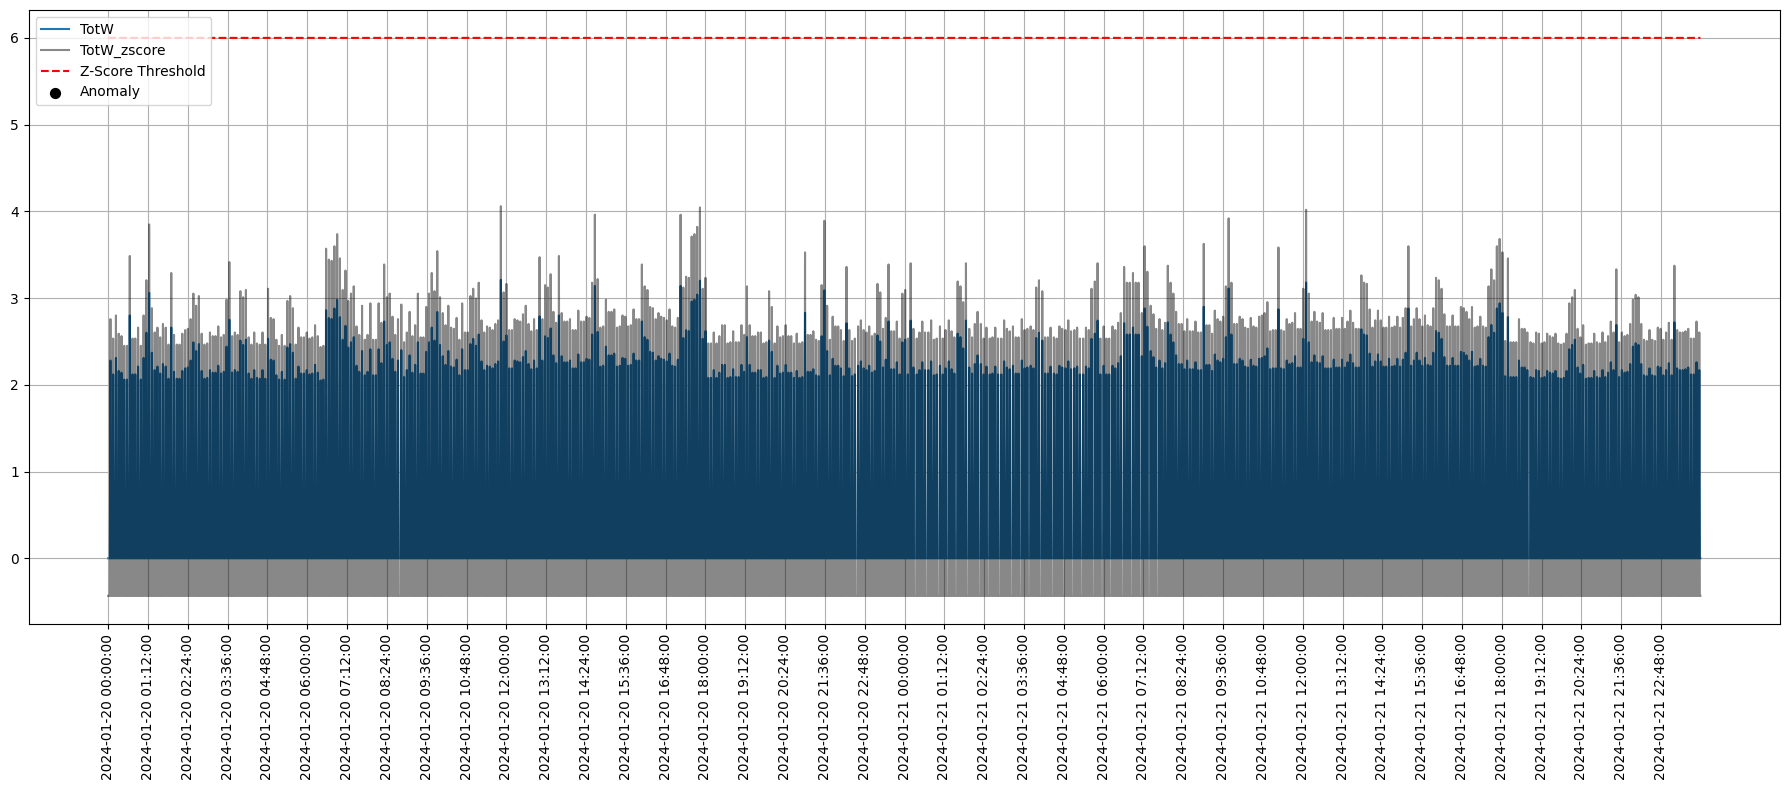

In [33]:
start = "2024-01-15"
end = "2024-01-22"

df_nonworking = df_nonworking[start:end]

# mark rows whose Z-Score goes above the threshold (or below the negative threshold) as anomalous
df_nonworking.loc[:, "anomalous"] = "no"
df_nonworking.loc[
    (df_nonworking["TotW_zscore"] >= df_nonworking["Threshold"]), "anomalous"
] = "high"

# todo: aggiungere confronti con la baseline qui
# df_nonworking.loc[(df_nonworking['TotW_zscore'] < -threshold), 'anomalous'] = "low"

plot_dataframe(
    df_nonworking,
    ["TotW", "TotW_zscore"],
    {"TotW": "#1F77B4", "TotW_zscore": "#00000077"},
)

plt.plot(
    df_nonworking["Threshold"], color="r", linestyle="--", label="Z-Score Threshold"
)

# highlight all anomalous data points
anomalous = df_nonworking[start:end][df_nonworking["anomalous"] != "no"]
plt.scatter(anomalous.index, anomalous["TotW"], color="black", s=50, label="Anomaly")

plt.legend(loc="upper left")

## Presentare le anomalie


In [34]:
df_working

,TotW,hour,dayofweek,week,TotW_zscore,Threshold,anomalous,high_flag,low_flag
datetime,,,,,,,,,
2024-01-01 00:00:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:01:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:02:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:03:00,0.00,0,0,0,-0.341425,6.0,False,False,True
2024-01-01 00:04:00,1.17,0,0,0,0.178601,6.0,False,False,False
...,...,...,...,...,...,...,...,...,...
2024-02-01 11:43:00,0.00,11,3,4,-0.341425,6.0,False,False,True
2024-02-01 11:44:00,0.00,11,3,4,-0.341425,6.0,False,False,True
2024-02-01 11:45:00,0.00,11,3,4,-0.341425,6.0,False,False,True


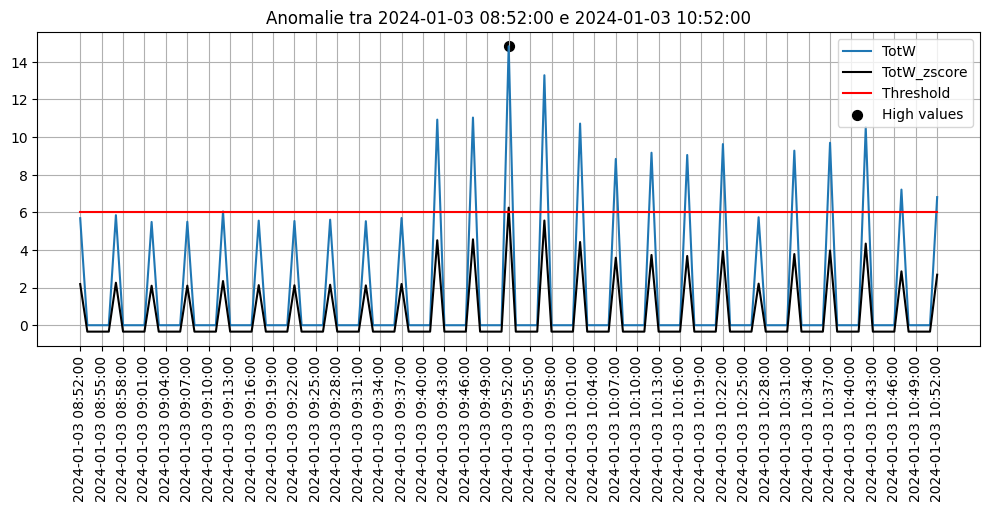

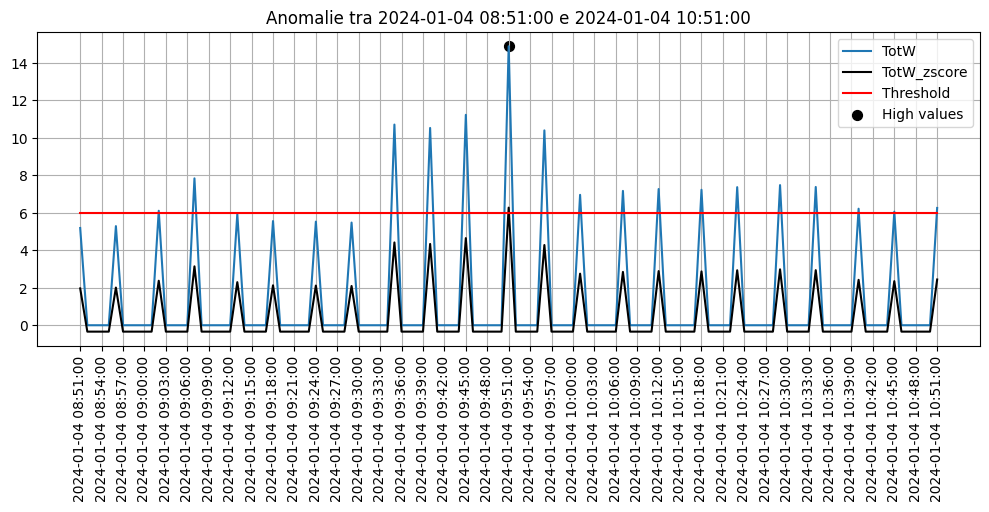

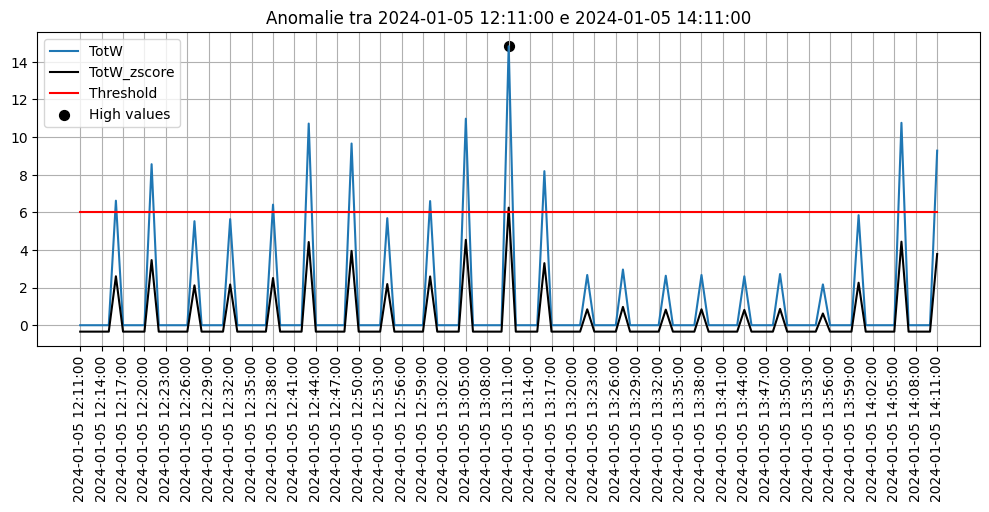

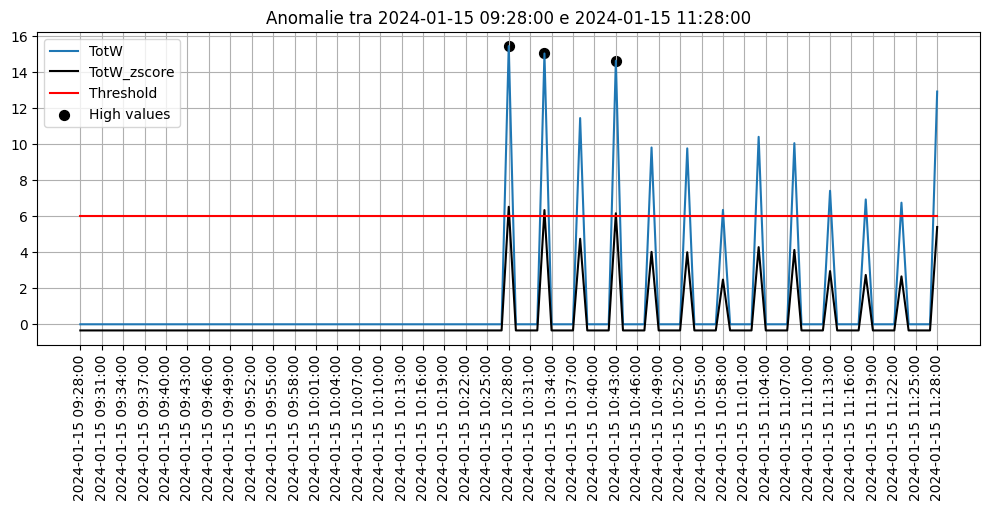

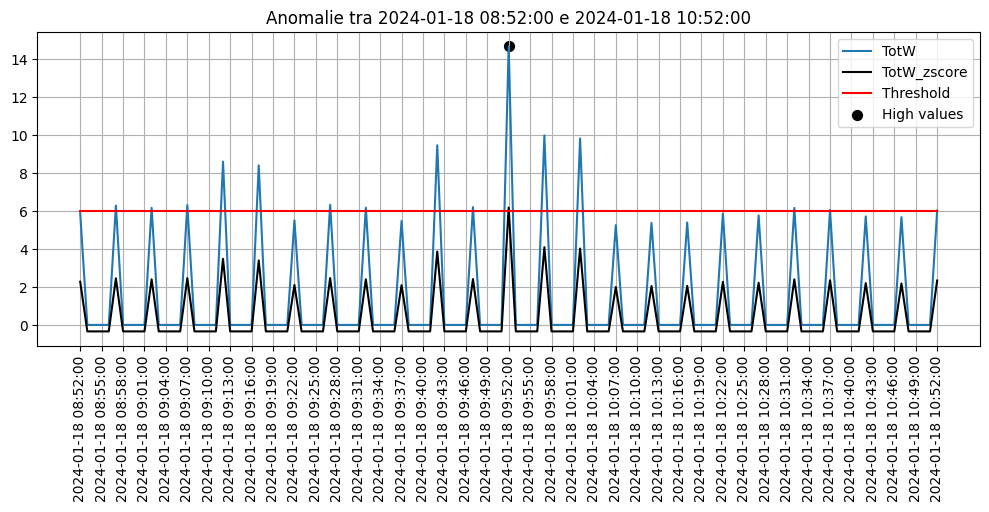

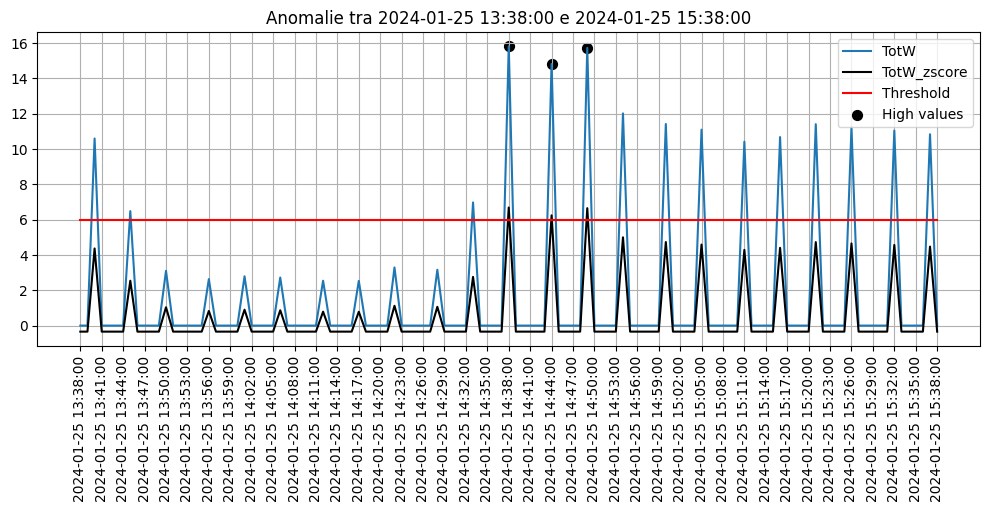

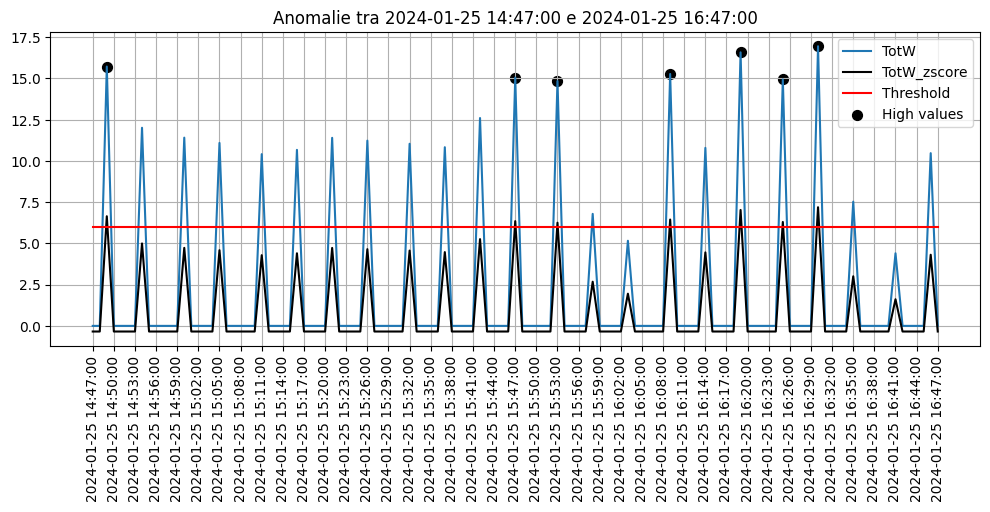

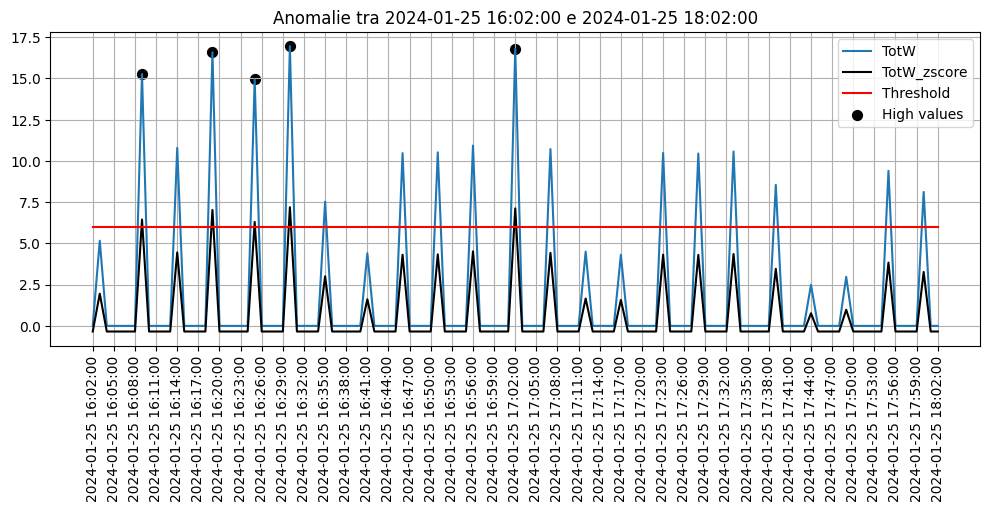

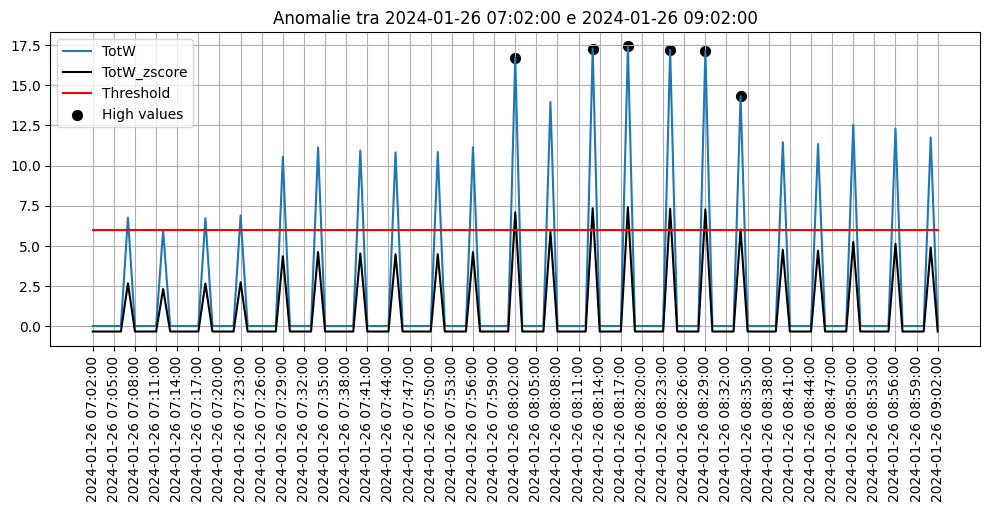

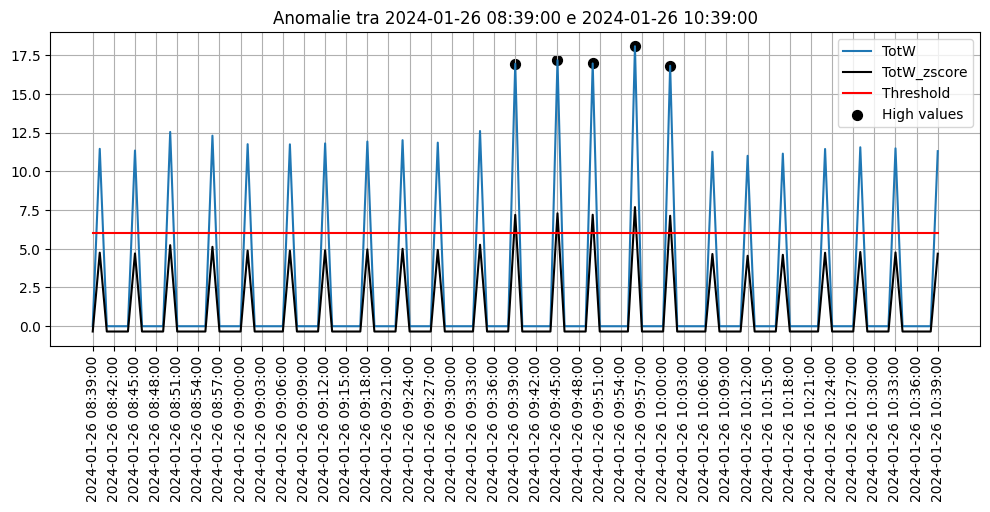

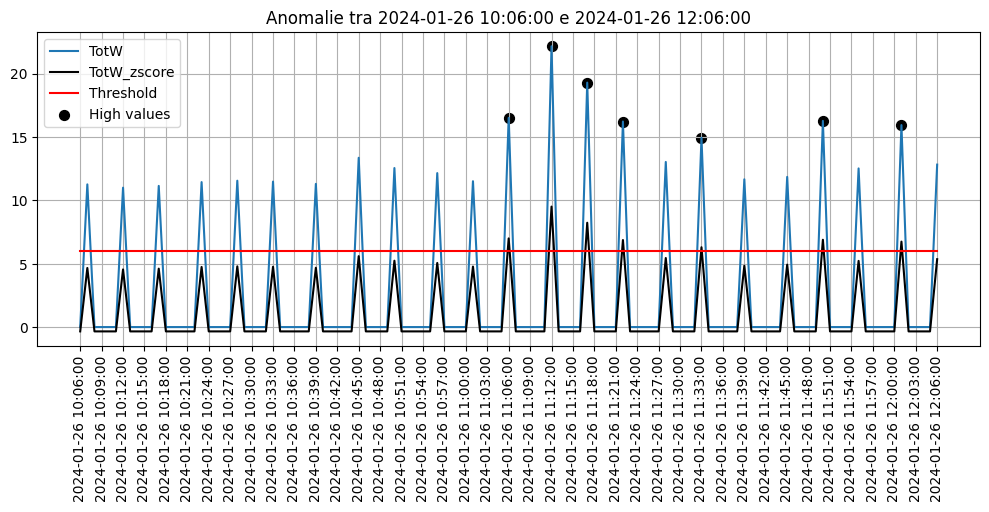

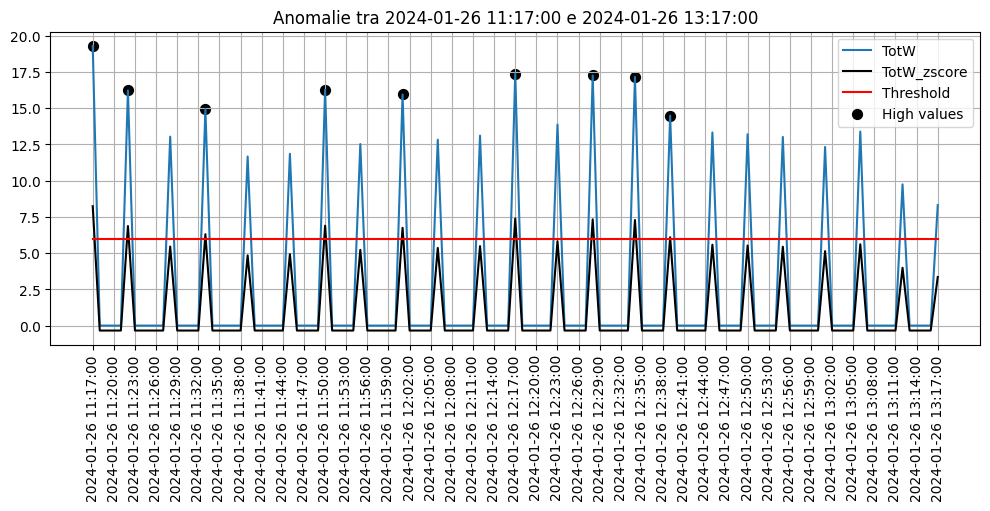

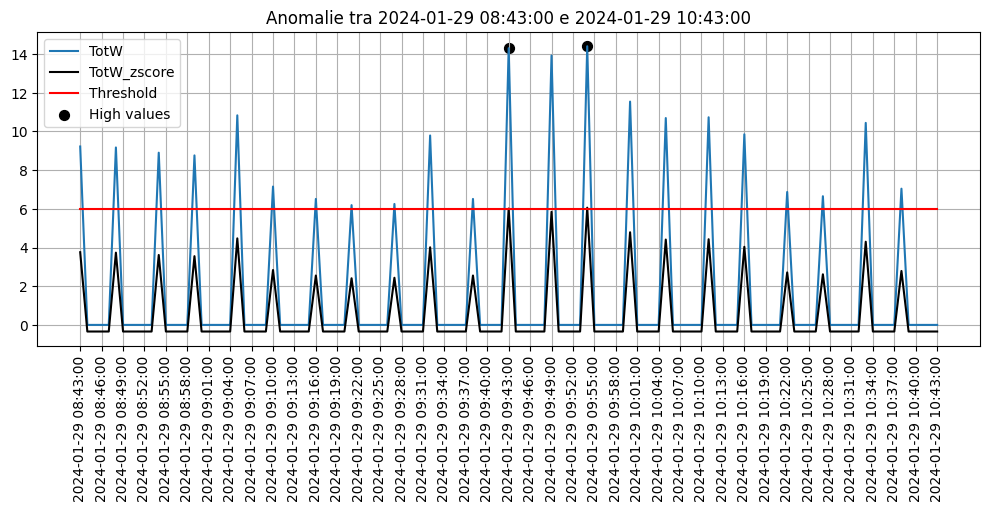

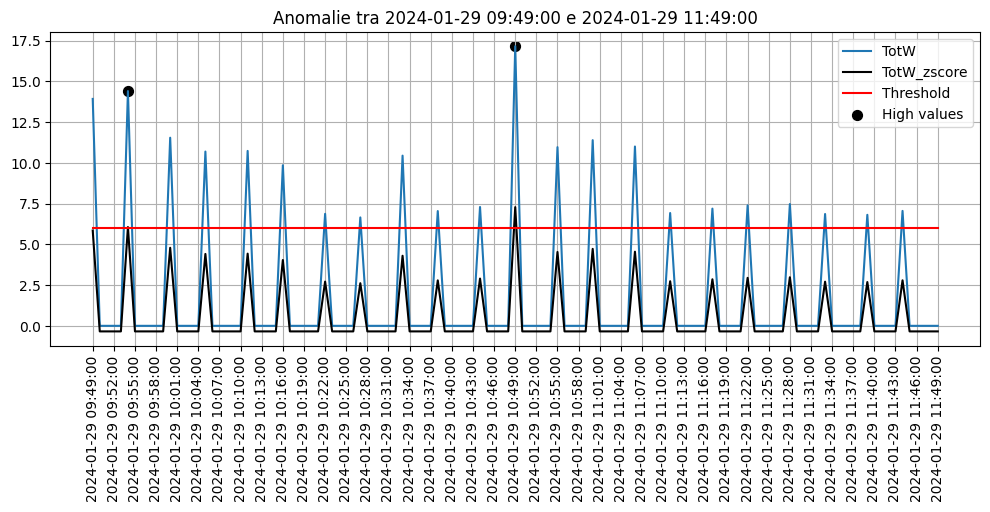

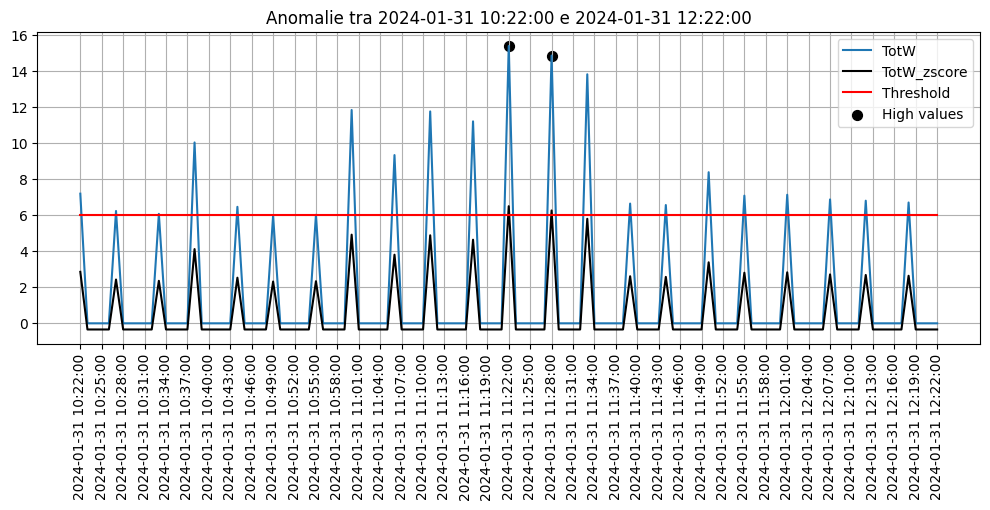

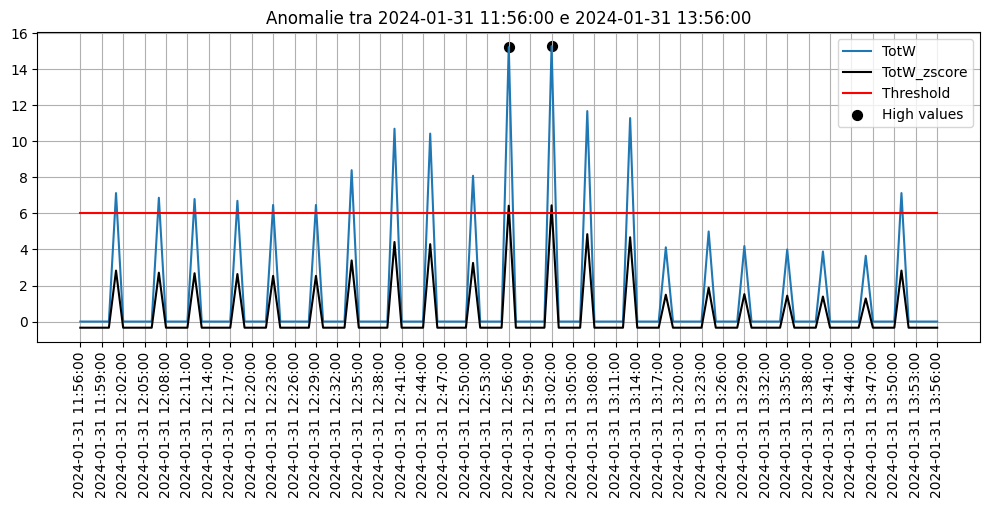

In [35]:
plot_anomalous_windows(df_working)